In [75]:
import pandas as pd
import datetime as dt
import numpy as np
import scipy.stats as stat
import matplotlib.pyplot as plt

In [76]:
data = pd.read_csv("data/time_series.csv", sep = ";")

first need to get a column that represents time, but can also be interpreted by pandas

In [78]:
def get_time(sec):
    sec = sec.iloc[0]
    time = dt.datetime.fromtimestamp( sec ).time()
    return time.hour*100 + time.minute

In [79]:
data["hour"] = data.apply( get_time  , axis = 1)

now to get a data of 'mean' for each day

In [81]:
aaa = data.groupby( "hour" ).mean()

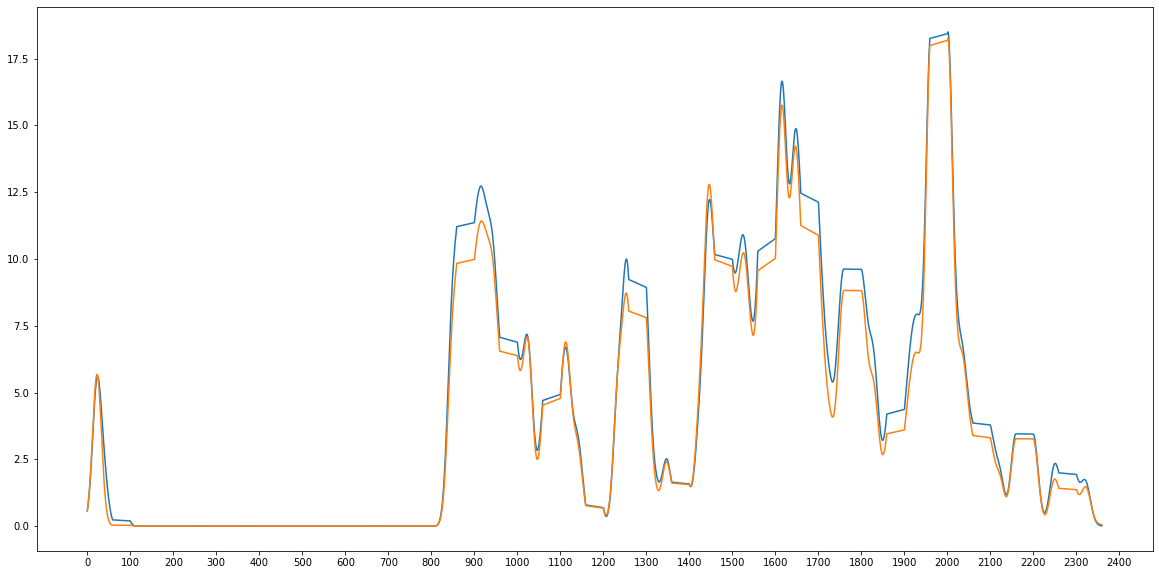

In [116]:
fig, ax = plt.subplots()

kernel = [ stat.norm.pdf(i*0.1) for i in range(-30,30)]
smoothed_lps = np.convolve( aaa.letters_per_second*10 , kernel , "same" )
smoothed_wpd = np.convolve( aaa.words_per_second*60 , kernel , "same" )

ax.plot( aaa.index , smoothed_lps )
ax.plot( aaa.index , smoothed_wpd )
fig.set_size_inches(20,10)

ax.set_xticks( [ i*100 for i in range(25) ] )
